#### Visualize the data

In [1]:
import sys
print(sys.executable)

c:\Users\etk02\anaconda3\envs\arcade_env\python.exe


In [2]:
# 安裝特定版本的 TensorFlow 與機率庫
!pip install tensorflow==2.10.0 cvnn tensorflow_datasets
!pip install --upgrade tensorflow-probability==0.18.0

# 確保其他必要的繪圖套件也在
!pip install pillow matplotlib tensorflow-datasets

In [2]:
import os
import tensorflow as tf
import numpy as np

from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from tensorflow import keras
import tensorflow_datasets as tfds
from keras.datasets import fashion_mnist
import matplotlib.patches as patches
from PIL import Image

tfds.disable_progress_bar()

from tensorflow.keras.models import Model
from tensorflow.keras.losses import Loss
from tensorflow.keras.layers import Layer,Lambda,InputLayer
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint

import cvnn.layers as complex_layers

import warnings
warnings.filterwarnings('ignore')

c:\Users\etk02\anaconda3\envs\arcade_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [21]:
size = 40
Hz = 399e9
lam = 3e8 / Hz
z = 0.03
rect_length = 400e-6

# Define the traning parameters
BUFFER_SIZE = 5000
BATCH_SIZE_PER_REPLICA = 32 #8
BATCH_SIZE = BATCH_SIZE_PER_REPLICA * 1

keep_training = False
learning_rate = 3e-3
epochs = 15

# load the dataset
datasets, info = tfds.load(name='fashion_mnist', with_info=True, as_supervised=True, data_dir='./data')

fashion_mnist_train, fashion_mnist_test = datasets['train'], datasets['test']

num_train = info.splits['train'].num_examples
num_test = info.splits['test'].num_examples

### 1.Peprocessing the images     
二值化， 1表示有光， 0表示无光

In [22]:
def preprocess(image, label):
    encode_in_phase_channel = False
    encode_in_amplitude_channel = not(encode_in_phase_channel)
    label = tf.one_hot(tf.cast(label, tf.int32), 10)   # convert the label to categorial, or one-hot coded
    
    up_sampling_size = int(0.8*size)
    padding_size = (size - up_sampling_size)//2
    image = tf.cast(image, tf.float32)
    # Step1: upsample the image 
    up_sampling_image = tf.image.resize(image,
                                        size=[up_sampling_size,up_sampling_size],
                                        method='nearest')
    up_sampling_image = up_sampling_image / 255.0
    
    # Step2: zeor padding
    zero_padded_image = tf.pad(up_sampling_image,
                                paddings=[[padding_size,padding_size],[padding_size,padding_size],[0,0]],
                                mode="CONSTANT",constant_values=0)
    if encode_in_amplitude_channel: 
        # Step3 :Binarize
        zeros = tf.zeros_like(zero_padded_image)
        ones = tf.ones_like(zero_padded_image)

        binarized_images = tf.where(zero_padded_image > 0.28, ones, zeros)  # 图像预处理: 转成二值图

        return tf.cast(binarized_images, dtype=tf.complex64), label
    
    if encode_in_phase_channel: 
        # Step3 : get phase image
        phase_image = tf.math.exp(2*np.pi*1j*tf.cast(zero_padded_image,dtype=tf.complex64))
        return phase_image, label
   
    
train_dataset = fashion_mnist_train.map(preprocess).cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
test_dataset = fashion_mnist_test.map(preprocess).batch(BATCH_SIZE)

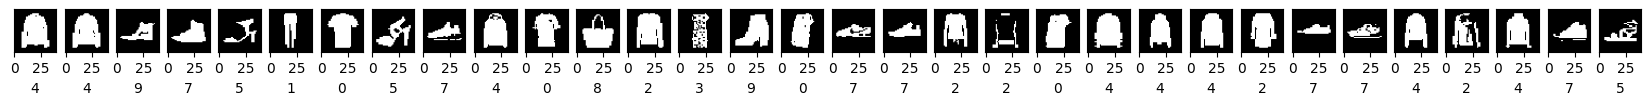

In [23]:
# plot the phase(angle) of the phase images
rows, cols = 1, BATCH_SIZE_PER_REPLICA
fig = plt.figure(figsize=(21,8))
for images, labels in test_dataset.take(1):
        for i in range(cols):
            fig.add_subplot(rows,cols,i+1)
            image = np.abs(images[i].numpy()).squeeze()
            # print(np.min(np.abs(images[i].numpy()).squeeze())) # check the amplitude of the phase object
            plt.imshow(image,cmap='gray')
            label = np.argmax(labels[i].numpy())
            ax = plt.gca()
            ax.axes.xaxis.set_visible(True)
            ax.axes.yaxis.set_visible(False)
            plt.xlabel(str(label))

### 2.Build the Diffraction layer using Angular Spectrum method

### Angular Spectrum Propagation
$$U_1(x,y) =\mathcal{F}^{-1}[\mathcal{F} U_0(x,y)\mathcal{F}h(x,y)]$$

$$U_1(x,y) =\mathcal{F}^{-1}[\mathcal{F} U_0(x,y) H(f_x,f_y)]$$


This can be described using Fourier transforms.The first Fourier transform decomposes the initial field into plane waves. To propagate the plane waves, we multiply each wave by a complex phase factor, and then we take the inverse Fourier transform to add all the propagated plane waves back together.

To implement Angular spectrum propagation, the Fouier transform of the initial field is first multiplied with the phase factor $$H=e^{ik_zz}$$, where $k_z$is a function of the spatial frequencies $$k_z=\sqrt{k^2-k_x^2-k_y}$$where $$  k = \frac{2\pi}{\lambda}$$ and $k_x$ and $k_y$ are related to the spatial frequencies $f_x$ and $f_y$ by a factor of $2\pi$ $$k_{x,y} = 2\pi f_{x,y}$$

Hence the complex exponential can be written in terms of the Fourier coordinates $f_x$ and $f_y$, that is 

$$H=e^{ik_zz},k_z = 2\pi \sqrt{\frac{1}{\lambda}-f_x-f_y}$$

Descretized spatial freqnency $f_x = k*\Delta f = \frac{k}{N \Delta x}$  
Interval between the spatial frequencies $\Delta f = \frac{1}{N \Delta x}=\frac{1}{L}$,where $L$ denotes the field of view in object space

In [24]:
class Diffraction_Layer(Layer):
    def __init__(self, size =size, Hz = Hz,z = z,rect_length = rect_length):
        super(Diffraction_Layer, self).__init__()
        self.size = size
        self.layer_size = size * rect_length       # layer size
        self.dx = rect_length
        self.prop_dist = z
        self.wavelength = 3e8/ Hz
        self.propagator = self.angular_spectrum_propagator()
   
    def build(self, input_shape):
        '''Create the state of the layer (weights)'''
        phase_init = tf.random_normal_initializer()
        self.phase = tf.Variable(name= "phase",
                                initial_value=phase_init(shape=(self.size,self.size), dtype='float32'),
                                trainable=True,
                                constraint=lambda t: tf.where((t <2*np.pi)&(t >0), t,2*np.pi*tf.random.normal([1])))
                                # constraint=lambda t: tf.clip_by_value(t, 0, 2*np.pi)) # 这样做会让准确率降低
        # To help with the 3D-printing and fabrication of the D2NN design, 
        # a sigmoid function was used to constrain the phase value of each neuron
   
    def angular_spectrum_propagator(self):
        L = self.layer_size
        dx = self.dx
        prop_dist = self.prop_dist
        wavelength = self.wavelength
        fx = np.arange(-1/(2*dx), 1/(2.*dx), 1/L)
        [FX, FY] = np.meshgrid(fx, fx)
        H = np.exp(-1j*np.pi*wavelength*prop_dist*(np.square(FX) + np.square(FY)))
        H = np.fft.fftshift(H)
        return tf.constant(H, 'complex64')
    
    @tf.function
    def call(self, inputs):
        inputs = tf.cast(inputs, 'complex64')
        conv_x = tf.map_fn(self.apply_conv, inputs)
        return tf.multiply(conv_x,tf.math.exp(1j*tf.cast(self.phase,dtype=tf.complex64)))

    def apply_conv(self, x):
        conv_x = self.conv2dfft(self.propagator, x)
        return conv_x
             
    def conv2dfft(self, A, B):
        B = tf.signal.fft2d(tf.signal.fftshift(B))
        fftAB = tf.math.multiply(A, B)
        return tf.signal.ifftshift(tf.signal.ifft2d(fftAB))
    

#### Notice
For ___tf.cast()___: In case of casting from real types to complex types(complex64), the imaginary part of the returned value is set to 0.    

In [25]:
class Propogation(Layer):
    def __init__(self, units =size,Hz = Hz, z = z, rect_length =rect_length):
        '''Initialize the diffraction layer attributes'''
        super(Propogation, self).__init__()
        self.layer_size = units * rect_length       # layer size
        self.dx = rect_length
        self.prop_dist = z
        self.wavelength = 3e8/ Hz
        self.propagator = self.angular_spectrum_propagator()
   
    def angular_spectrum_propagator(self):
        L = self.layer_size
        dx = self.dx
        prop_dist = self.prop_dist
        wavelength = self.wavelength
        fx = np.arange(-1/(2*dx), 1/(2.*dx), 1/L)
        [FX, FY] = np.meshgrid(fx, fx)
        H = np.exp(-1j*np.pi*wavelength*prop_dist*(np.square(FX) + np.square(FY)))
        H = np.fft.fftshift(H)
        return tf.constant(H, 'complex64')
    
    @tf.function
    def call(self, inputs):
        inputs = tf.cast(inputs, 'complex64')
        conv_x = tf.map_fn(self.apply_conv, inputs)
        return conv_x

    def apply_conv(self, x):
        conv_x = self.conv2dfft(self.propagator, x)
        return conv_x
             
    def conv2dfft(self, A, B):
        B = tf.signal.fft2d(tf.signal.fftshift(B))
        fftAB = tf.math.multiply(A, B)
        return tf.signal.ifftshift(tf.signal.ifft2d(fftAB))
        

Origen code

In [ ]:
# class Detector(Layer):
#     def __init__(self, units=200):
#         '''Initialize the instance attributes'''
#         super(Detector, self).__init__()
#         self.units = units
    
#     @tf.function
#     def call(self, inputs):
#         ''' Converts output to one hot form
#         Applies softmax'''
        
#         def rang(arr,shape,size=size,base = 500):
#             x0 = shape[0] * size // base
#             y0 = shape[2] * size // base
#             delta = (shape[1]-shape[0])* size // base
#             return arr[x0:x0+delta,y0:y0+delta]
        
#         def reduce_mean(tf_):
#             return tf.reduce_mean(tf_)
        
#         def _ten_regions(a):
#             return tf.map_fn(reduce_mean,tf.convert_to_tensor([
#                 rang(a,(120,170,120,170)),
#                 rang(a,(120,170,240,290)),
#                 rang(a,(120,170,360,410)),
#                 rang(a,(220,270,120,170)),
#                 rang(a,(220,270,200,250)),
#                 rang(a,(220,270,280,330)),
#                 rang(a,(220,270,360,410)),
#                 rang(a,(320,370,120,170)),
#                 rang(a,(320,370,240,290)),
#                 rang(a,(320,370,360,410))
#             ]))
        
#         def ten_regions(logits):
#             return tf.map_fn(_ten_regions,tf.abs(logits),dtype=tf.float32)

#         return tf.nn.softmax(ten_regions(tf.abs(inputs))) # logits_abs

Fix detector

In [26]:
class Detector(Layer):
    def __init__(self, units=10):
        super(Detector, self).__init__()
        self.units = units
    
    @tf.function
    def call(self, inputs):
        def _get_regions(a):
            # 使用 3-4-3 陣型，確保 10 個類別完全不重疊
            # 格式: a[y_start:y_end, x_start:x_end]
            regions = [
                # 第一排 (3個框), Y軸 4~12
                a[4:12, 4:12],   # Class 0
                a[4:12, 16:24],  # Class 1
                a[4:12, 28:36],  # Class 2
                
                # 第二排 (4個框), Y軸 16~24
                a[16:24, 1:9],   # Class 3
                a[16:24, 11:19], # Class 4
                a[16:24, 21:29], # Class 5
                a[16:24, 31:39], # Class 6
                
                # 第三排 (3個框), Y軸 28~36
                a[28:36, 4:12],  # Class 7
                a[28:36, 16:24], # Class 8
                a[28:36, 28:36]  # Class 9
            ]
            return tf.stack([tf.reduce_mean(r) for r in regions])
        
        intensity = tf.abs(inputs)**2 
        logits = tf.map_fn(_get_regions, intensity, dtype=tf.float32)
        return tf.nn.softmax(logits)

In [27]:
# MES
# def loss_function(y_label,logits_abs):
#     return tf.reduce_sum(tf.square(logits_abs-y_label))

# Categorical Crossentropy loss function
def loss_function(y_label, logits_abs):
    return tf.reduce_mean(
        tf.keras.losses.categorical_crossentropy(y_label, logits_abs)
    )

In [28]:
def get_D2NN_model():
    inputs = complex_layers.complex_input(shape=(size,size))
    h1 = Diffraction_Layer(size,Hz,z)(inputs)
    h2 = Diffraction_Layer(size,Hz,z)(h1)
    h3 = Diffraction_Layer(size,Hz,z)(h2)
    h4 = Diffraction_Layer(size,Hz,z)(h3)
    h5 = Diffraction_Layer(size,Hz,z)(h4)
    propogation = Propogation(size,Hz,z=0.01)(h5)
    out = Detector()(propogation)
    return tf.keras.Model(inputs, out)

D2NN = get_D2NN_model()

D2NN.summary()
# plot_model(D2NN, show_shapes=True, show_layer_names=True, to_file='D2NN-model.png')

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (ComplexInput)      [(None, 40, 40)]          0         
                                                                 
 diffraction__layer_5 (Diffr  (None, 40, 40)           1600      
 action_Layer)                                                   
                                                                 
 diffraction__layer_6 (Diffr  (None, 40, 40)           1600      
 action_Layer)                                                   
                                                                 
 diffraction__layer_7 (Diffr  (None, 40, 40)           1600      
 action_Layer)                                                   
                                                                 
 diffraction__layer_8 (Diffr  (None, 40, 40)           1600      
 action_Layer)                                             

In [30]:
if keep_training:
    D2NN.load_weights('./training_results/D2NN_AS')

lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate = learning_rate,
    decay_steps=100000,
    decay_rate=0.96,
    staircase=True)

D2NN.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
             loss=loss_function,
             metrics=['accuracy'])

checkpoint_path = './training_results/D2NN_AS'
checkpoint = ModelCheckpoint(filepath=checkpoint_path,
                             save_weights_only=True,
                             save_freq='epoch')

history = D2NN.fit(train_dataset,
                   epochs=epochs,
                   validation_data=test_dataset,
                   callbacks=[checkpoint])

Epoch 1/15
1875/1875 [==============================] - 236s 125ms/step - loss: 1.8239 - accuracy: 0.5921 - val_loss: 1.6549 - val_accuracy: 0.6369
Epoch 2/15
1875/1875 [==============================] - 182s 97ms/step - loss: 1.6088 - accuracy: 0.6539 - val_loss: 1.5935 - val_accuracy: 0.6515
Epoch 3/15
1875/1875 [==============================] - 182s 97ms/step - loss: 1.5668 - accuracy: 0.6595 - val_loss: 1.5525 - val_accuracy: 0.6515
Epoch 4/15
1875/1875 [==============================] - 182s 97ms/step - loss: 1.5465 - accuracy: 0.6625 - val_loss: 1.5487 - val_accuracy: 0.6522
Epoch 5/15
1875/1875 [==============================] - 181s 97ms/step - loss: 1.5334 - accuracy: 0.6641 - val_loss: 1.5364 - val_accuracy: 0.6483
Epoch 6/15
1875/1875 [==============================] - 182s 97ms/step - loss: 1.5242 - accuracy: 0.6668 - val_loss: 1.5242 - val_accuracy: 0.6535
Epoch 7/15
1875/1875 [==============================] - 182s 97ms/step - loss: 1.5162 - accuracy: 0.6675 - val_loss: 

plot training result

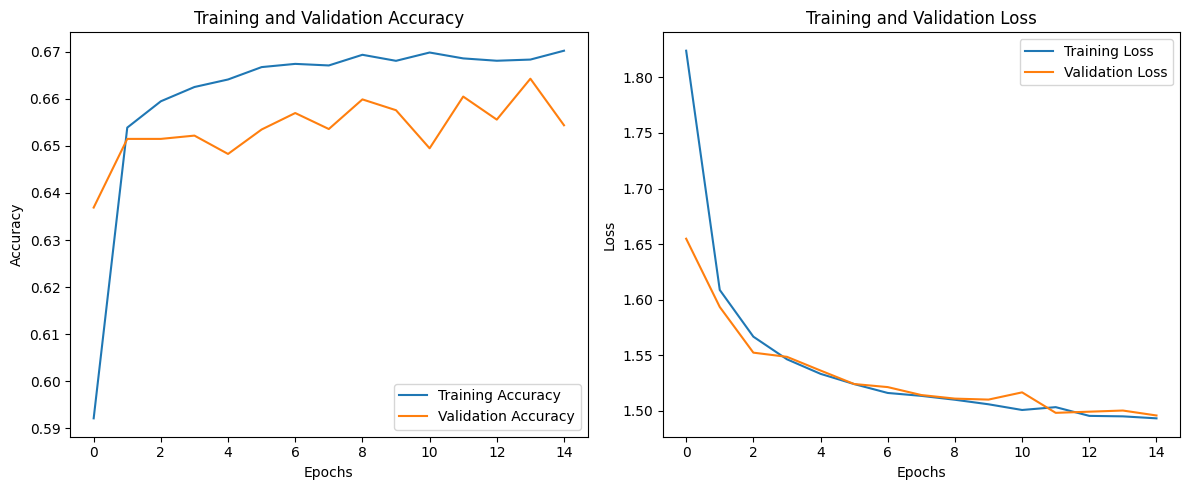

In [31]:
import matplotlib.pyplot as plt

# 1. 繪製 Accuracy 圖表
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# 2. 繪製 Loss 圖表
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### 3. Extracting weights from model
- Neurons’ phase values were converted into a relative height map (Δ𝑧=𝜆$\phi$/2𝜋Δ𝑛)    
  ,where Δ𝑛 is the refractive index difference between the 3D printing material (VeroBlackPlus RGD875) and air
- save the height map to a numpy file

In [32]:
D2NN.load_weights('./training_results/D2NN_AS')
# print(D2NN.layers)
# print(D2NN.layers[1].weights)
# print(D2NN.layers[5].get_weights()) # get the numpy arrays for the parameters of the layer
# print(D2NN.get_layer('diffraction__layer_4').phase)

# Extract all the weights from the model
weights = []
# D2NN 中的 diffraction layer 从第二层开始，第一层是 input layer
for l in range(1,5+1):
    weights.append(np.squeeze(D2NN.layers[l].get_weights())) 
    
# Map the weights into range [0, 2*pi]
for l in range(0,5):
    for i in range(0,size):
        for j in range(0,size):
            while (weights[l][i][j] < 0):
                    weights[l][i][j] += 2*np.pi
            while(weights[l][i][j] > 2*np.pi):
                weights[l][i][j] -= 2*np.pi
print("The max value in wights is: " + str(np.max(weights)))
print("The mim value in wights is: " + str(np.min(weights)))

The max value in wights is: 6.279258
The mim value in wights is: 0.0023255004


In [33]:
# Convert the weights to height map
lam = 3e8 / Hz        # wavelength of the optical wave

# VeroBlackPlus RGD875, refractive index: 1.7227
# SiO2 (Glass) - Palik, Refractive Index: 1.47012
material_refractive_index = 1.7227
air_refractive_index = 1.0003

delta_n = material_refractive_index - air_refractive_index

height_map = (lam*np.array(weights)) / (2*np.pi*delta_n)         

# Check the shape and save it to np file
print("The shape of the height map for all layers:",end=' ')
print(np.shape(np.array(height_map)))
print("Max and min value in height_map are: " + str(np.max(height_map)) + ", "+ str(np.min(height_map))+"\n")

np.save('height_map.npy',np.array(height_map))
print("height_map.npy has saved successfully")

The shape of the height map for all layers: (5, 40, 40)
Max and min value in height_map are: 0.0010401575, 3.8521856e-07

height_map.npy has saved successfully


In [34]:
lam = 3e8 / Hz        # wavelength of the optical wave
material_refractive_index = 1.7227
air_refractive_index = 1.0003

delta_n = material_refractive_index - air_refractive_index
# get the height map for the filter
test_dataset = fashion_mnist_test.map(preprocess).batch(BATCH_SIZE)
for images, labels in test_dataset.take(1):
    images = tfds.as_numpy(images)
    for _ in range(1):
        image_phase = np.angle(images[7]).squeeze()
        for i in range(0,size):
            for j in range(0,size):
                while (image_phase[i][j] < 0):
                    image_phase[i][j] += 2*np.pi
                while(image_phase[i][j] > 2*np.pi):
                    image_phase[i][j] -= 2*np.pi
        # print(np.shape(image_phase))
        
        filter_height_map = (lam*np.array(image_phase)) / (2*np.pi*delta_n)
        np.save('filter_height_map.npy',np.array(filter_height_map))
        print("The shape of the filter height map for all layers:",end=' ')
        print(np.shape(np.array(filter_height_map)))
        print("Max and min value in height_map are: " + str(np.max(filter_height_map)) + ", "+ str(np.min(filter_height_map))+"\n")
        print("filter_height_map.npy has saved successfully")

The shape of the filter height map for all layers: (40, 40)
Max and min value in height_map are: 0.0, 0.0

filter_height_map.npy has saved successfully


### 4.Evaluation

In [15]:
# """Plot the region of the ten detectors"""
# detector_plane = np.zeros([size,size])

# ten_detector_regions = [[120,170,120,170],
#                         [120,170,240,290],
#                         [120,170,360,410],
#                         [220,270,120,170],
#                         [220,270,200,250],
#                         [220,270,280,330],
#                         [220,270,360,410],
#                         [320,370,120,170],
#                         [320,370,240,290],
#                         [320,370,360,410]] 

# def get_range(shape,size=size,base = 500):
#             x0 = shape[0] * size // base
#             y0 = shape[2] * size // base
#             delta = (shape[1]-shape[0])* size // base
#             x1 = x0+delta
#             y1 = y0+delta
#             return x0,x1,y0,y1

# for i in range(0,10):
#     x0,x1,y0,y1 = get_range(ten_detector_regions[i])
#     # print([x0,x1,y0,y1])
#     detector_plane[x0:x1,y0:y1] = 1

# # plot the detector region
# rows, cols = 1 ,1
# fig = plt.figure(figsize=(7,7))
# plt.imshow(detector_plane,cmap='gray')

In [35]:
# predict for a bunch(= buffer size = 16) image
for images, labels in test_dataset.take(1):
    label =  np.argmax(labels[:].numpy(), axis=1)
    predict = np.argmax(D2NN.predict(images,verbose=0), axis=1)
    print("Ground truth:    ", label)
    print("Predicted result:" , predict)
    print(label==predict)

Ground truth:     [4 4 9 7 5 1 0 5 7 4 0 8 2 3 9 0 7 7 2 2 0 4 4 4 2 7 7 4 2 4 7 5]
Predicted result: [2 4 9 9 9 1 0 9 7 4 0 8 2 3 9 3 7 7 2 2 0 2 4 4 2 7 7 4 2 4 7 9]
[False  True  True False False  True  True False  True  True  True  True
  True  True  True False  True  True  True  True  True False  True  True
  True  True  True  True  True  True  True False]


### 5.Simulation in Python

In [36]:
def angular_spectrum_propagator(x, z=z): # x: input U0
    L = size * rect_length
    dx = rect_length
    prop_dist = z
    wavelength = 3e8/ Hz
    fx = np.arange(-1/(2*dx), 1/(2.*dx), 1/L)
    [FX, FY] = np.meshgrid(fx, fx)
    H = np.exp(-1j*np.pi*wavelength*prop_dist*(np.square(FX) + np.square(FY)))
    H = np.fft.fftshift(H)
    
    def conv2dfft(A, B):
        B = np.fft.fft2(np.fft.fftshift(B))
        fftAB = np.multiply(A, B)
        return np.fft.ifftshift(np.fft.ifft2(fftAB))
    return conv2dfft(H, x) # U1

In [37]:
D2NN.load_weights('./training_results/D2NN_AS')
phase = []
# D2NN 中的 diffraction layer 从第二层开始，第一层是 input layer
for l in range(1,5+1):
    phase.append(np.squeeze(D2NN.layers[l].get_weights()))
print(np.shape(phase[0][:][:]))

(40, 40)


newone

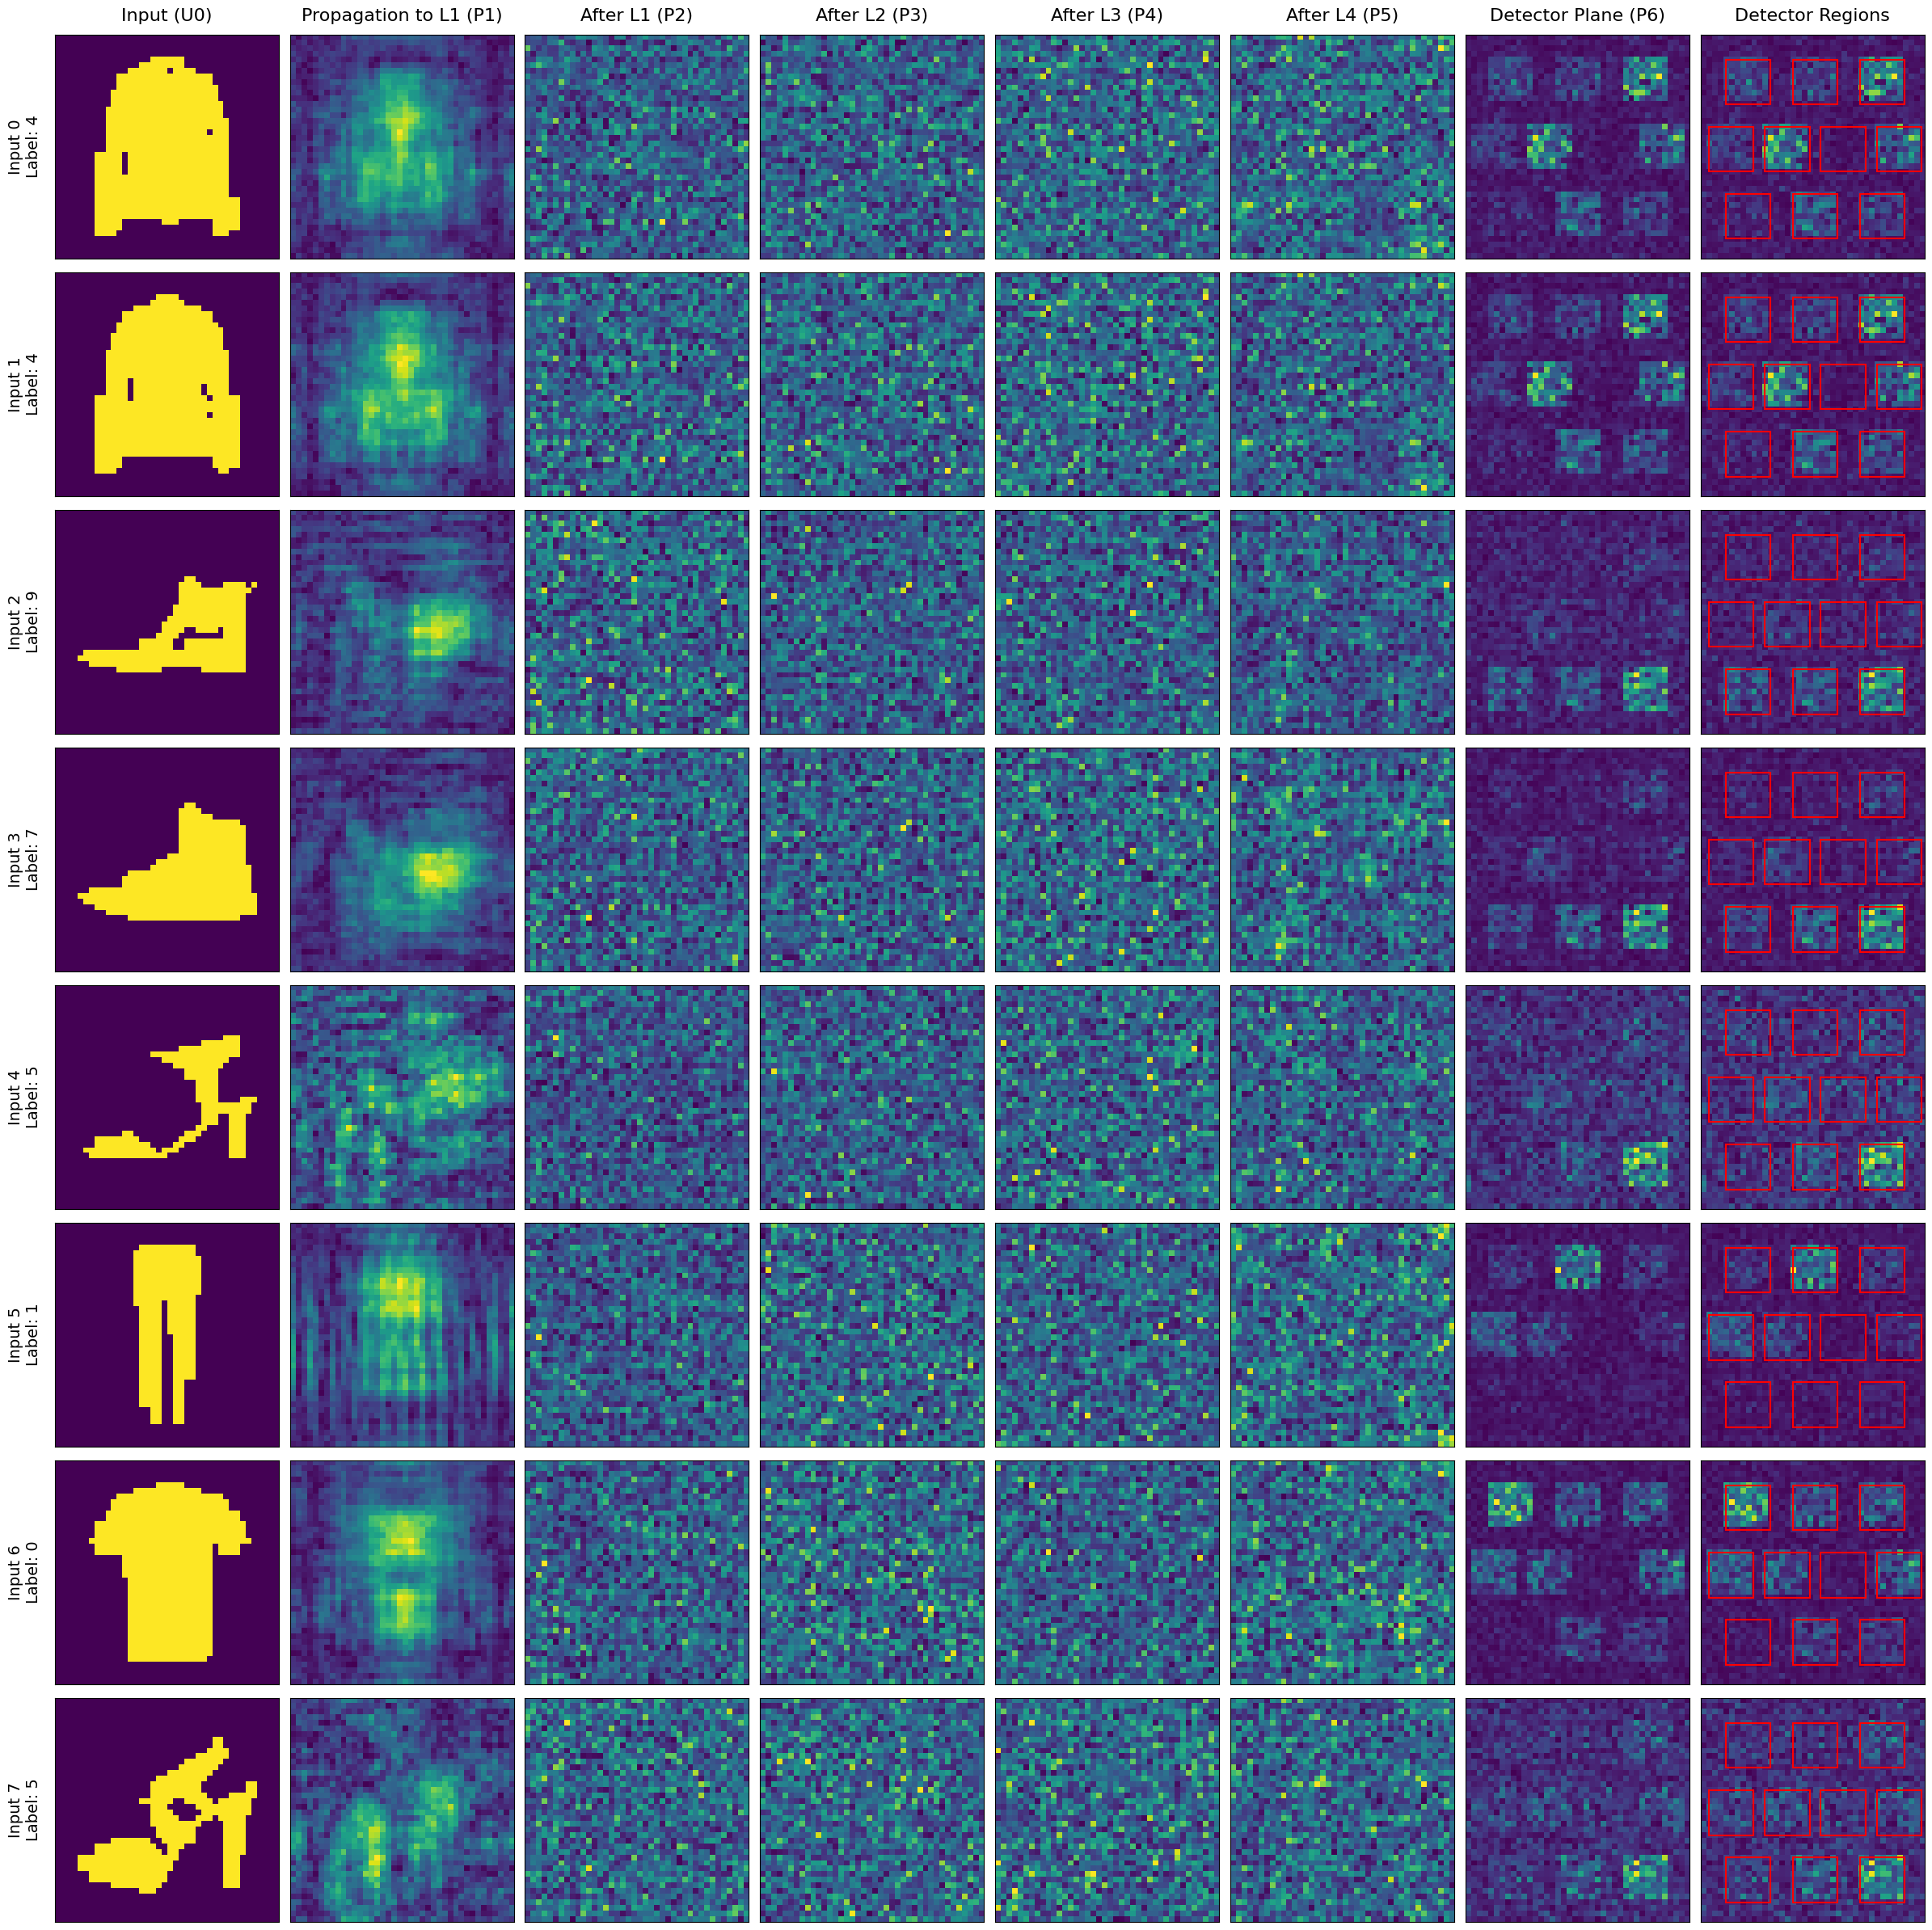

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. 取得一個 batch (8張圖) 的資料
for images, labels in test_dataset.take(1):
    images_np = images.numpy()
    labels_np = labels.numpy() 

# 2. 建立 8x8 的畫布 (稍微調整尺寸避免過大卡頓)
fig, axes = plt.subplots(8, 8, figsize=(24, 24)) 

# 定義每一直欄 (Column) 的標題
titles = ["Input (U0)", "Propagation to L1 (P1)", "After L1 (P2)", 
          "After L2 (P3)", "After L3 (P4)", "After L4 (P5)", 
          "Detector Plane (P6)", "Detector Regions"]

# 3. 完美對齊您 Detector 類別的偵測器座標
# 定義格式：(x_start, y_start, width, height)
# 陣列切片 a[y1:y2, x1:x2] 對應的框線為 (x1, y1, x2-x1, y2-y1)
detector_boxes = [
    # 第一排 (3個)
    (4, 4, 8, 8),   (16, 4, 8, 8),  (28, 4, 8, 8),
    # 第二排 (4個)
    (1, 16, 8, 8),  (11, 16, 8, 8), (21, 16, 8, 8), (31, 16, 8, 8),
    # 第三排 (3個)
    (4, 28, 8, 8),  (16, 28, 8, 8), (28, 28, 8, 8)
]

for row_idx in range(8):
    # 取出第 row_idx 張圖片作為這回合的輸入
    U0 = images_np[row_idx].squeeze()
    
    # --- 執行光學傳播計算 ---
    P1 = angular_spectrum_propagator(U0)
    t_0 = np.exp(1j * phase[0][:][:])
    P2 = angular_spectrum_propagator(P1 * t_0)
    
    t_1 = np.exp(1j * phase[1][:][:])
    P3 = angular_spectrum_propagator(P2 * t_1)
    
    t_2 = np.exp(1j * phase[2][:][:])
    P4 = angular_spectrum_propagator(P3 * t_2)
    
    t_3 = np.exp(1j * phase[3][:][:])
    P5 = angular_spectrum_propagator(P4 * t_3)
    
    t_4 = np.exp(1j * phase[4][:][:])
    P6 = angular_spectrum_propagator(P5 * t_4, z=0.01)
    
    # 將算完的 8 個階段依序放進清單
    row_images = [np.abs(U0), np.abs(P1), np.abs(P2), np.abs(P3), 
                  np.abs(P4), np.abs(P5), np.abs(P6), np.abs(P6)]
    
    for col_idx in range(8):
        # 定位到網格中正確的格子
        ax = axes[row_idx, col_idx]
        im = ax.imshow(row_images[col_idx], cmap='viridis')
        
        # 只在「最上面那一列 (row 0)」顯示階段標題
        if row_idx == 0:
            ax.set_title(titles[col_idx], fontsize=16, pad=12)
            
        # 只在「最左邊那一欄 (col 0)」標示這是哪一張圖與它的 Label
        if col_idx == 0:
            actual_label = labels_np[row_idx].argmax() if len(labels_np.shape) > 1 else labels_np[row_idx]
            ax.set_ylabel(f"Input {row_idx}\nLabel: {actual_label}", fontsize=14, labelpad=12)
        
        # 關閉 X 和 Y 軸的刻度數字
        ax.set_xticks([])
        ax.set_yticks([])
        
        # 如果是最後一欄 (col_idx == 7)，精準套上您的偵測器紅框
        if col_idx == 7:
            for (x, y, w, h) in detector_boxes:
                rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor='red', facecolor='none')
                ax.add_patch(rect)

# 4. 顯示圖表
plt.tight_layout()
plt.show()

oldone


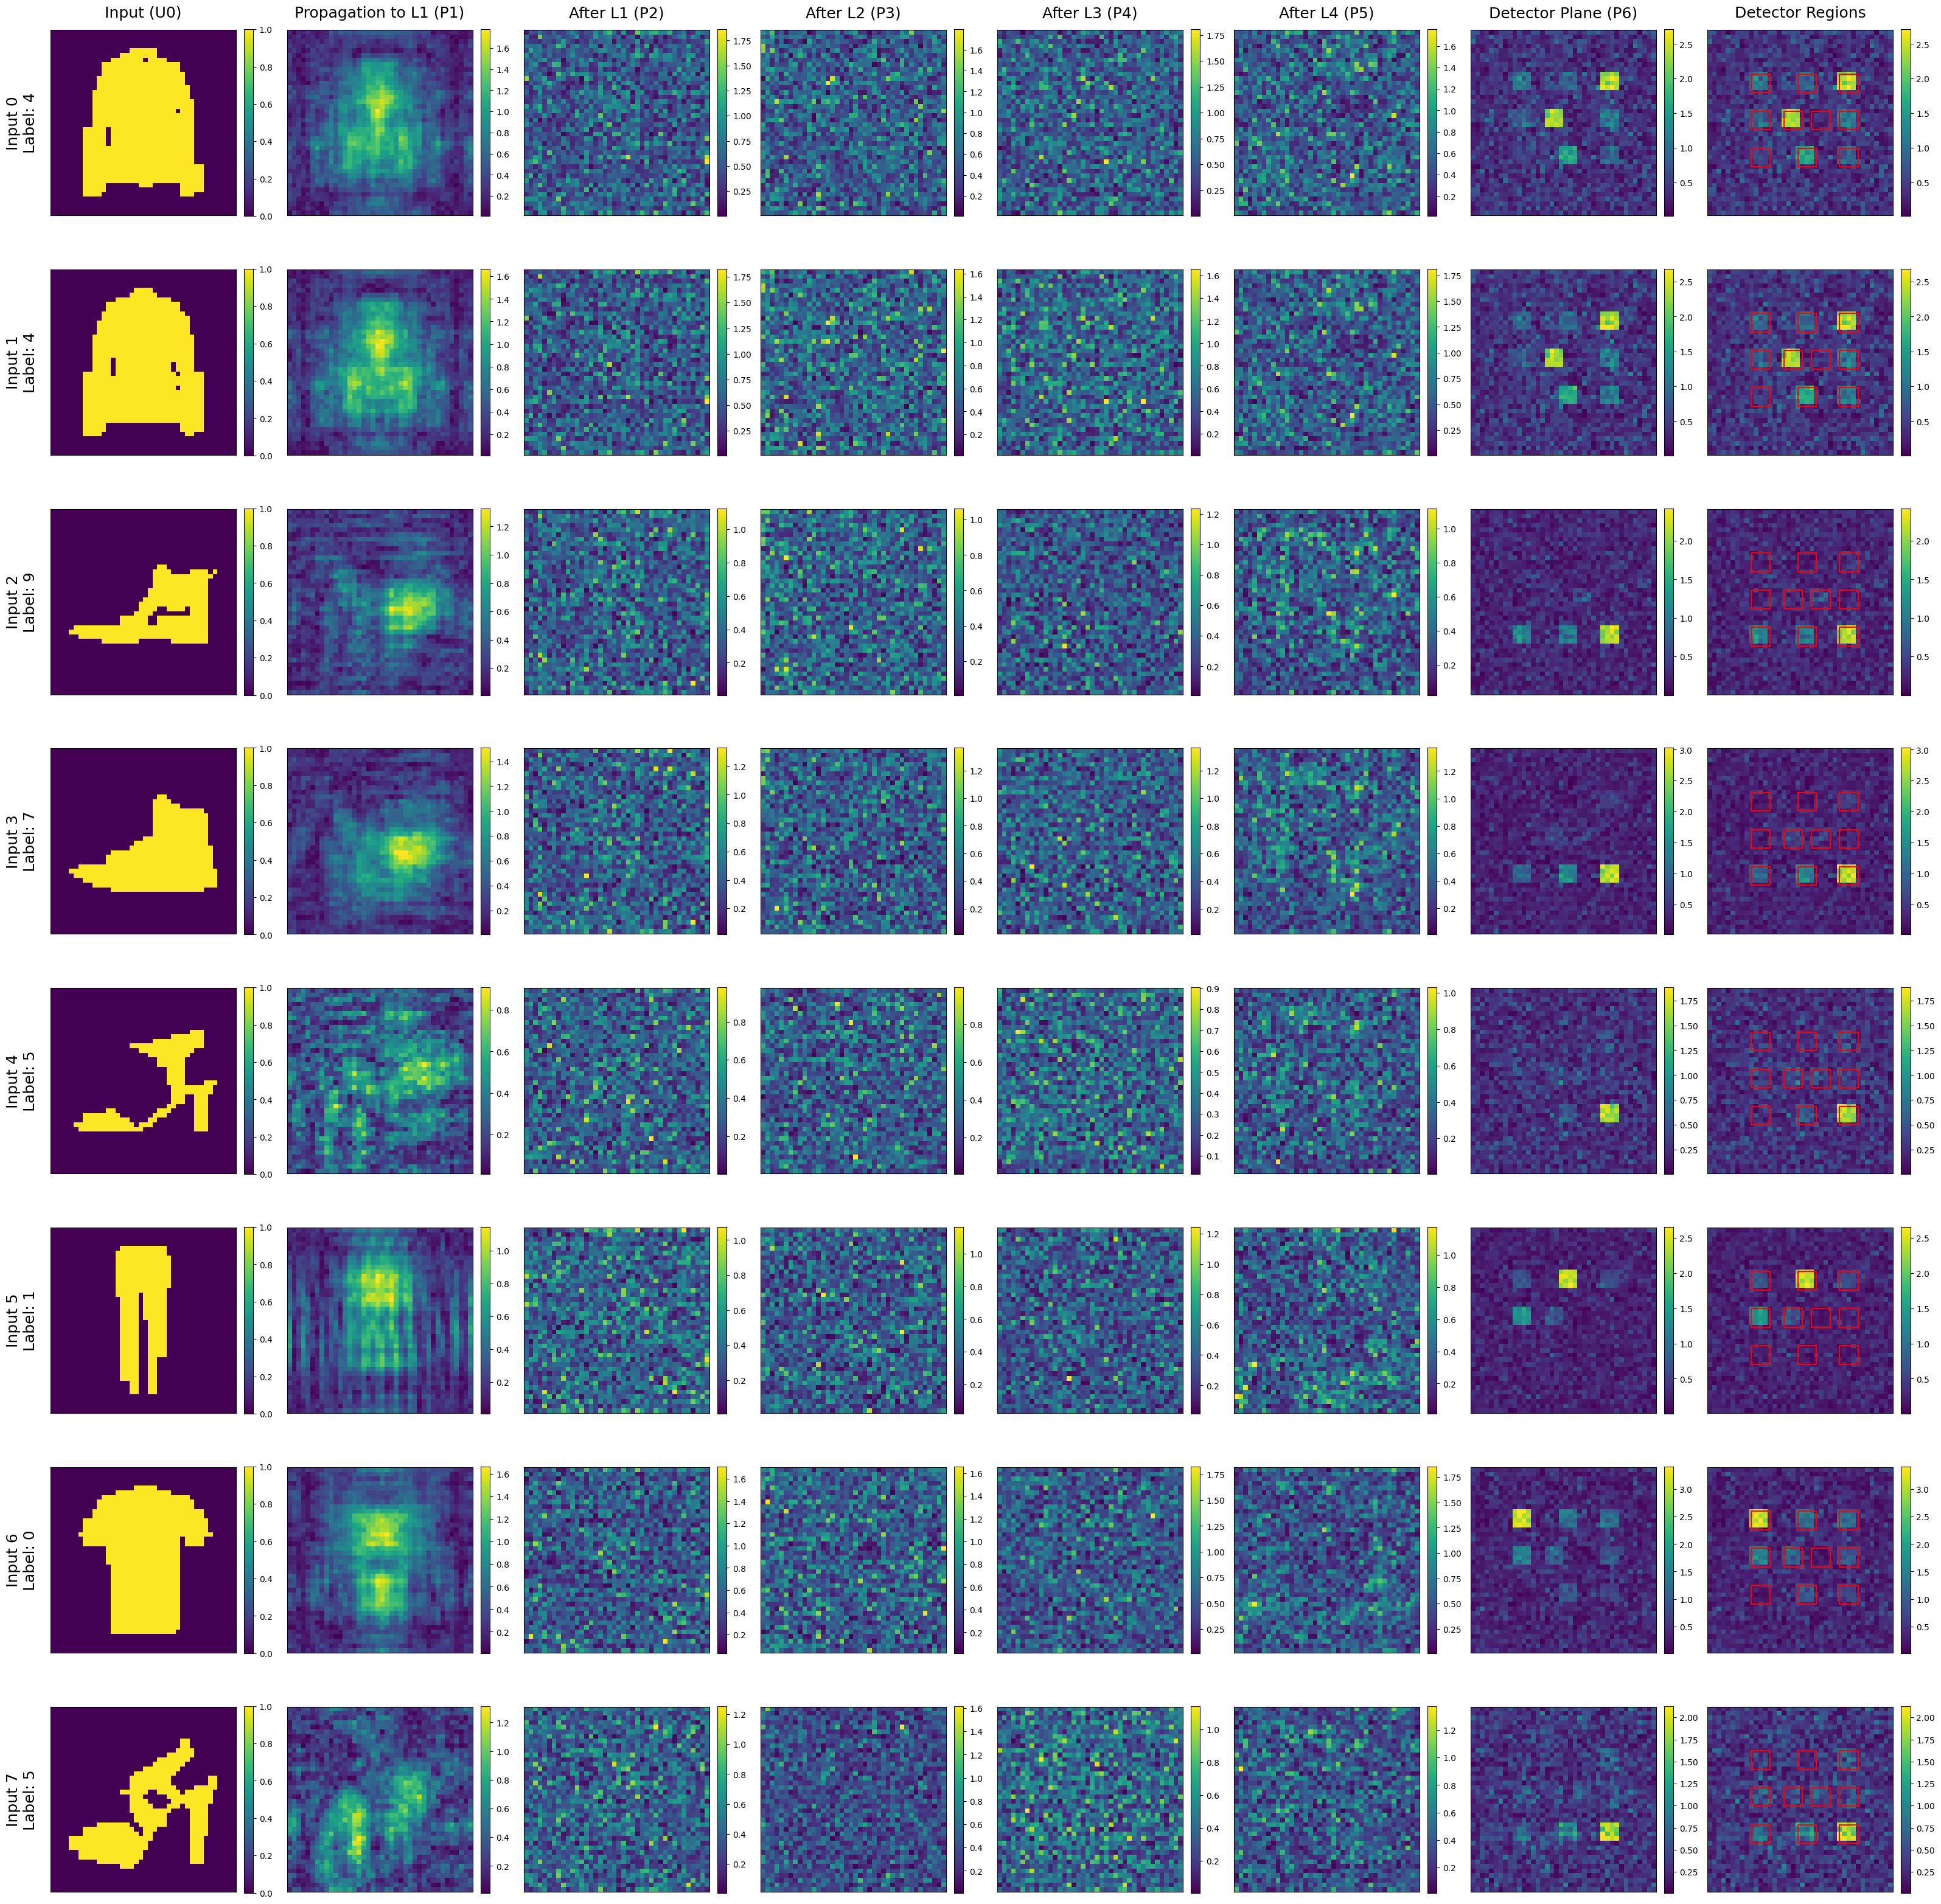

In [ ]:


# 1. 取得一個 batch (8張圖) 的資料
for images, labels in test_dataset.take(1):
    # 將 Tensor 轉換為 numpy 陣列以便後續使用
    images_np = images.numpy()
    labels_np = labels.numpy() 

# 2. 建立 8x8 的畫布
# 因為有 64 張圖，畫布尺寸(figsize)必須設得夠大，例如 32x32
fig, axes = plt.subplots(8, 8, figsize=(32, 32)) 

# 定義每一直欄 (Column) 的標題
titles = ["Input (U0)", "Propagation to L1 (P1)", "After L1 (P2)", 
          "After L2 (P3)", "After L3 (P4)", "After L4 (P5)", 
          "Detector Plane (P6)", "Detector Regions"]

# 提前算好偵測器框線的座標與大小，節省資源
i = size / 500
delta = int(i*170) - int(i*120)
detector_coords = [
    (int(i*240), int(i*120)), (int(i*360), int(i*120)), (int(i*120), int(i*120)),
    (int(i*120), int(i*220)), (int(i*200), int(i*220)), (int(i*280), int(i*220)), (int(i*360), int(i*220)),
    (int(i*120), int(i*320)), (int(i*240), int(i*320)), (int(i*360), int(i*320))
]

for row_idx in range(8):
    # 取出第 row_idx 張圖片作為這回合的輸入
    U0 = images_np[row_idx].squeeze()
    
    # --- 執行光學傳播計算 ---
    P1 = angular_spectrum_propagator(U0)
    
    t_0 = np.exp(1j*phase[0][:][:])
    P2 = angular_spectrum_propagator(P1*t_0)
    
    t_1 = np.exp(1j*phase[1][:][:])
    P3 = angular_spectrum_propagator(P2*t_1)
    
    t_2 = np.exp(1j*phase[2][:][:])
    P4 = angular_spectrum_propagator(P3*t_2)
    
    t_3 = np.exp(1j*phase[3][:][:])
    P5 = angular_spectrum_propagator(P4*t_3)
    
    t_4 = np.exp(1j*phase[4][:][:])
    P6 = angular_spectrum_propagator(P5*t_4, z=0.01)
    
    # 將算完的 8 個階段依序放進清單
    row_images = [np.abs(U0), np.abs(P1), np.abs(P2), np.abs(P3), 
                  np.abs(P4), np.abs(P5), np.abs(P6), np.abs(P6)]
    

    for col_idx in range(8):
        # 定位到網格中正確的格子
        ax = axes[row_idx, col_idx]
        im = ax.imshow(row_images[col_idx], cmap='viridis')
        
        # 【排版優化】只在「最上面那一列 (row 0)」顯示階段標題
        if row_idx == 0:
            ax.set_title(titles[col_idx], fontsize=18, pad=15)
            
        # 【排版優化】只在「最左邊那一欄 (col 0)」標示這是哪一張圖與它的 Label
        if col_idx == 0:
            # 這裡用 argmax 是因為通常 D2NN 標籤是 one-hot encoding，如果是純數字就把 .argmax() 拿掉
            actual_label = labels_np[row_idx].argmax() if len(labels_np.shape) > 1 else labels_np[row_idx]
            ax.set_ylabel(f"Input {row_idx}\nLabel: {actual_label}", fontsize=18, labelpad=15)
        
        # 關閉 X 和 Y 軸的刻度數字 (但保留上面的 ylabel)
        ax.set_xticks([])
        ax.set_yticks([])
        
        # 加上顏色條 (如果 64 個顏色條覺得太擠，可以把這行註解掉)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        
        # 如果是最後一欄 (col_idx == 7)，加上紅色的偵測器框線
        if col_idx == 7:
            for coord in detector_coords:
                # 必須每次建立一個新的 Rectangle 物件，不能重複使用同一個
                rect = patches.Rectangle(coord, delta, delta, linewidth=1.5, edgecolor='r', facecolor='none')
                ax.add_patch(rect)

# 5. 顯示終極 8x8 大圖表
plt.tight_layout()
plt.show()

開始計算 8 張圖的光學傳播...
設定畫布與初始化...
正在渲染 Frame 0/7: Input (U0)...
正在渲染 Frame 0/7: Input (U0)...
正在渲染 Frame 1/7: Propagation to L1 (P1)...
正在渲染 Frame 2/7: After L1 (P2)...
正在渲染 Frame 3/7: After L2 (P3)...
正在渲染 Frame 4/7: After L3 (P4)...
正在渲染 Frame 5/7: After L4 (P5)...
正在渲染 Frame 6/7: Detector Plane (P6)...
正在渲染 Frame 7/7: Detector Regions...
🎉 大功告成！橫向對照動畫已成功儲存為 Side_by_Side_Propagation.gif
正在渲染 Frame 0/7: Input (U0)...


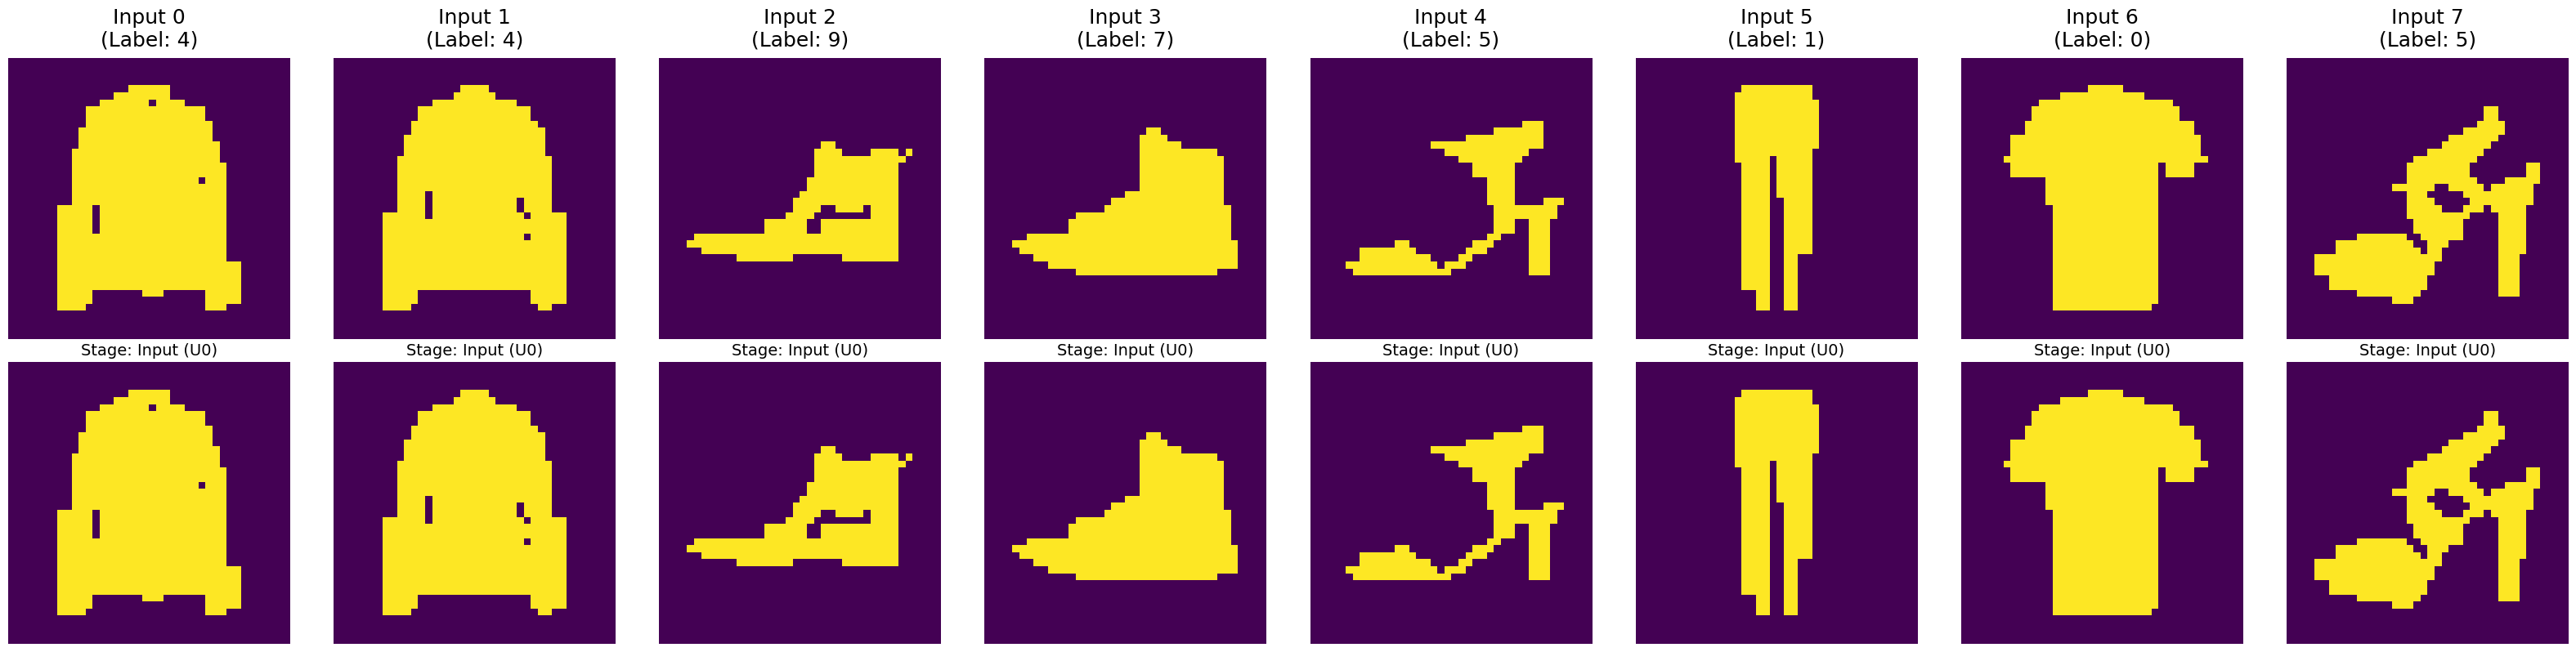

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
import numpy as np

# 1. 取得資料並預先計算相位板
for images, labels in test_dataset.take(1):
    images_np = images.numpy()
    labels_np = labels.numpy() 

t_0 = np.exp(1j*phase[0][:][:])
t_1 = np.exp(1j*phase[1][:][:])
t_2 = np.exp(1j*phase[2][:][:])
t_3 = np.exp(1j*phase[3][:][:])
t_4 = np.exp(1j*phase[4][:][:])

titles = ["Input (U0)", "Propagation to L1 (P1)", "After L1 (P2)", 
          "After L2 (P3)", "After L3 (P4)", "After L4 (P5)", 
          "Detector Plane (P6)", "Detector Regions"]

frames_data = [[] for _ in range(8)]

print("開始計算 8 張圖的光學傳播...")
for col_idx in range(8):
    U0 = images_np[col_idx].squeeze()
    P1 = angular_spectrum_propagator(U0)
    P2 = angular_spectrum_propagator(P1*t_0)
    P3 = angular_spectrum_propagator(P2*t_1)
    P4 = angular_spectrum_propagator(P3*t_2)
    P5 = angular_spectrum_propagator(P4*t_3)
    P6 = angular_spectrum_propagator(P5*t_4, z=0.01)
    
    stages = [np.abs(U0), np.abs(P1), np.abs(P2), np.abs(P3), 
              np.abs(P4), np.abs(P5), np.abs(P6), np.abs(P6)]
    
    for stage_idx in range(8):
        frames_data[stage_idx].append(stages[stage_idx])

print("設定畫布與初始化...")
# 為了容納橫向 8 張圖，我們把寬度拉長到 32，高度設為 8
fig, axes = plt.subplots(2, 8, figsize=(32, 8))

# 提前算好偵測器框線的座標與大小
scale_ratio = size / 500
delta = int(scale_ratio*170) - int(scale_ratio*120)
detector_coords = [
    (int(scale_ratio*240), int(scale_ratio*120)), (int(scale_ratio*360), int(scale_ratio*120)), (int(scale_ratio*120), int(scale_ratio*120)),
    (int(scale_ratio*120), int(scale_ratio*220)), (int(scale_ratio*200), int(scale_ratio*220)), (int(scale_ratio*280), int(scale_ratio*220)), (int(scale_ratio*360), int(scale_ratio*220)),
    (int(scale_ratio*120), int(scale_ratio*320)), (int(scale_ratio*240), int(scale_ratio*320)), (int(scale_ratio*360), int(scale_ratio*320))
]

ims_animated = []      # 只存放下排會動的 imshow 物件
detector_patches = []  # 存放下排的紅色框線物件

for col_idx in range(8):
    actual_label = labels_np[col_idx].argmax() if len(labels_np.shape) > 1 else labels_np[col_idx]
    

    ax_top = axes[0, col_idx]
    ax_top.imshow(frames_data[0][col_idx], cmap='viridis')
    ax_top.set_title(f"Input {col_idx}\n(Label: {actual_label})", fontsize=18, pad=10)
    ax_top.axis('off')
    
   
    ax_bottom = axes[1, col_idx]
    # 初始先畫上 U0 的畫面
    im = ax_bottom.imshow(frames_data[0][col_idx], cmap='viridis')
    ims_animated.append(im) # 把下排的圖存起來，等等給動畫更新用
    ax_bottom.set_title(f"Stage: {titles[0]}", fontsize=14, pad=10)
    ax_bottom.axis('off')
    
    # 在下排預先畫好紅框，但設為隱藏
    patch_list = []
    for coord in detector_coords:
        rect = patches.Rectangle(coord, delta, delta, linewidth=1.5, edgecolor='r', facecolor='none')
        rect.set_visible(False) 
        ax_bottom.add_patch(rect)
        patch_list.append(rect)
    detector_patches.append(patch_list)

plt.tight_layout()

def animate(frame_idx):
    print(f"正在渲染 Frame {frame_idx}/7: {titles[frame_idx]}...")
    
    is_last_frame = (frame_idx == 7)
    
    for col_idx in range(8):
        # 1. 替換下排圖片的資料
        ims_animated[col_idx].set_data(frames_data[frame_idx][col_idx])
        # 自動校準顏色條亮度
        ims_animated[col_idx].autoscale() 
        
        # 2. 更新下排的階段標題
        axes[1, col_idx].set_title(f"Stage: {titles[frame_idx]}", fontsize=14)
        
        # 3. 如果是最後一幀，顯示紅框
        for rect in detector_patches[col_idx]:
            rect.set_visible(is_last_frame)
            
    return ims_animated

# ==========================================
# 5. 輸出橫向雙層 GIF
# ==========================================
ani = animation.FuncAnimation(fig, animate, frames=8, interval=1500, blit=False)
ani.save('Side_by_Side_Propagation.gif', writer='pillow', fps=1, dpi=150)

print("🎉 大功告成！橫向對照動畫已成功儲存為 Side_by_Side_Propagation.gif")